# BiVariate and MultiVariate Analysis

#### Bivariate analysis is to examine the relationship between two variables — typically:
- One independent variable
- One target variable (income: <=50K or >50K)

### Categorical vs Income
 - For categorical variables, we use:
 - Cross-tabulation
 - Proportion comparison
 - Bar plots
 - Chi-square test (optional)

### Numerical vs Income
For numerical variables:
 - Boxplots
 - Mean comparison
 - Distribution plots

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")

In [3]:
df_train_test = pd.read_csv("df_train_test.csv") 

In [4]:
df_train_test.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'source', 'capital_gain_bin', 'capital_loss_bin',
       'net_capital', 'income_binary'],
      dtype='object')

In [5]:
df_train_test[['workclass', 'occupation']].value_counts()

workclass    occupation      
Private      Craft-repair        4744
             Sales               4439
             Adm-clerical        4205
             Other-service       4053
             Exec-managerial     3993
                                 ... 
Without-pay  Other-service          2
             Exec-managerial        1
             Craft-repair           1
             Sales                  1
             Transport-moving       1
Name: count, Length: 85, dtype: int64

# Do people earning >50K work more hours than those earning <=50K?

In [12]:
# Compare Mean Hours
df_train_test.groupby('income')['hours_per_week'].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,37128.0,38.842599,12.356307,1.0,35.0,40.0,40.0,99.0
>50K,11685.0,45.453145,11.091986,1.0,40.0,40.0,50.0,99.0


<Axes: xlabel='income', ylabel='hours_per_week'>

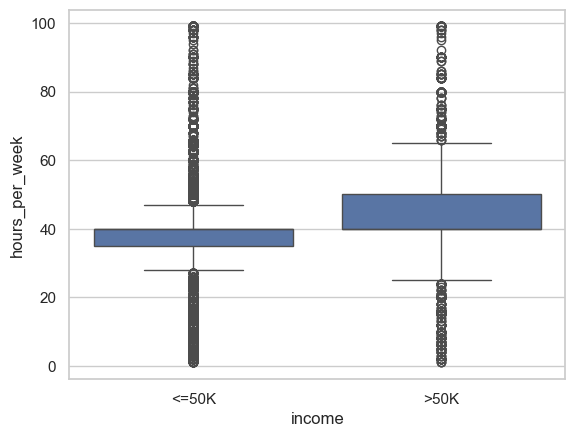

In [14]:
sns.boxplot(x='income', y='hours_per_week', data=df_train_test)

<span style="color: blue;"> **Hours per Week vs Income**

Compared working hours across income groups.
- People earning <=50K work on average 38.84 hours per week.  
- People earning >50K work on average 45.45 hours per week.  
- Median hours for both groups is 40, but the upper quartile is higher for >50K (50 vs 40).

Higher income individuals tend to work more hours on average. There is overlap, so hours alone are not a strong predictor, but it can be useful when combined with other features like age and education.</span>

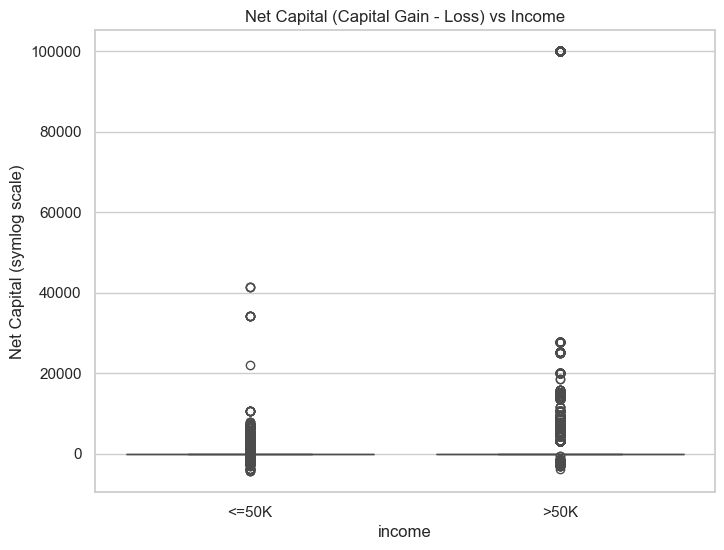

In [38]:
plt.figure(figsize=(8,6))

sns.boxplot(x='income', y='net_capital', data=df_train_test)
#plt.yscale('symlog')  # symmetric log scale handles zeros and skewness
plt.title('Net Capital (Capital Gain - Loss) vs Income')
plt.ylabel('Net Capital (symlog scale)')
plt.show()

<span style="color: blue;"> **Net Capital vs Income** </span>

<span style="color: blue;">
Most people have zero net capital in both income groups, but people earning >50K tend to have much higher capital gains than those earning <=50K. Despite the feature being highly right-skewed and zero-inflated, the relationship is **strong** — higher net capital clearly points toward higher income, making it a useful feature for the model.</span>

## Occupation vs Income

In [41]:
# find Within each occupation, what % earns >50K?
pd.crosstab(df_train_test['occupation'], df_train_test['income'], normalize='index') * 100

income,<=50K,>50K
occupation,,
Adm-clerical,86.305278,13.694722
Armed-Forces,66.666667,33.333333
Craft-repair,77.353856,22.646144
Exec-managerial,52.202498,47.797502
Farming-fishing,88.365837,11.634163
Handlers-cleaners,93.336552,6.663448
Machine-op-inspct,87.711163,12.288837
Other-service,95.852816,4.147184
Priv-house-serv,98.750000,1.250000


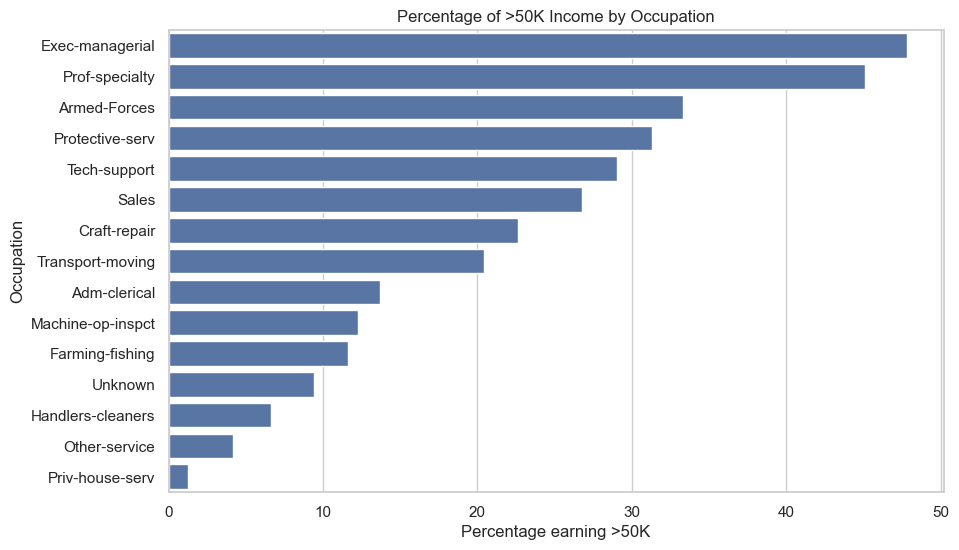

In [42]:
# Calculate percentage of >50K per occupation
occ_income = pd.crosstab(df_train_test['occupation'], df_train_test['income'], normalize='index') * 100
occ_income = occ_income.sort_values(by='>50K', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=occ_income['>50K'], y=occ_income.index)
plt.title('Percentage of >50K Income by Occupation')
plt.xlabel('Percentage earning >50K')
plt.ylabel('Occupation')
plt.show()

<span style="color: blue;"> **Occupation vs Income summary**</span>

<span style="color: blue;">
    
 - The percentage of individuals earning >50K within each occupation category.
    
 - Executive and professional occupations show the highest proportion of high-income individuals, while manual and service-based occupations have a significantly lower percentage of >50K earners.
   
 - This indicates that occupation is a strong predictor of income and will likely be an important feature in model training.</span>

# MultiVariate Analysis

#### Are higher income people both older and working more hours?
 - Are there clusters of <=50K vs >50K?

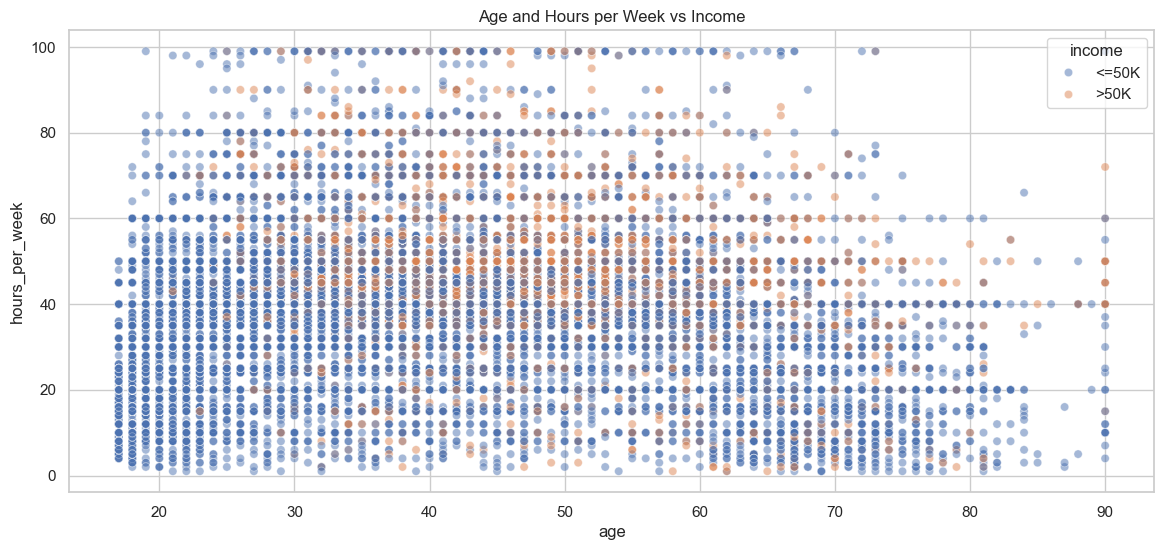

In [17]:
plt.figure(figsize=(14,6))
sns.scatterplot(x='age', y='hours_per_week', hue='income', data=df_train_test, alpha=0.5)
plt.title('Age and Hours per Week vs Income')
plt.show()

### This scatter plot shows that higher-income individuals (>50K) tend to work more hours and are generally concentrated in middle to older age ranges, but there is considerable overlap with lower-income individuals across all ages and hours worked.  

<Axes: xlabel='education_num', ylabel='hours_per_week'>

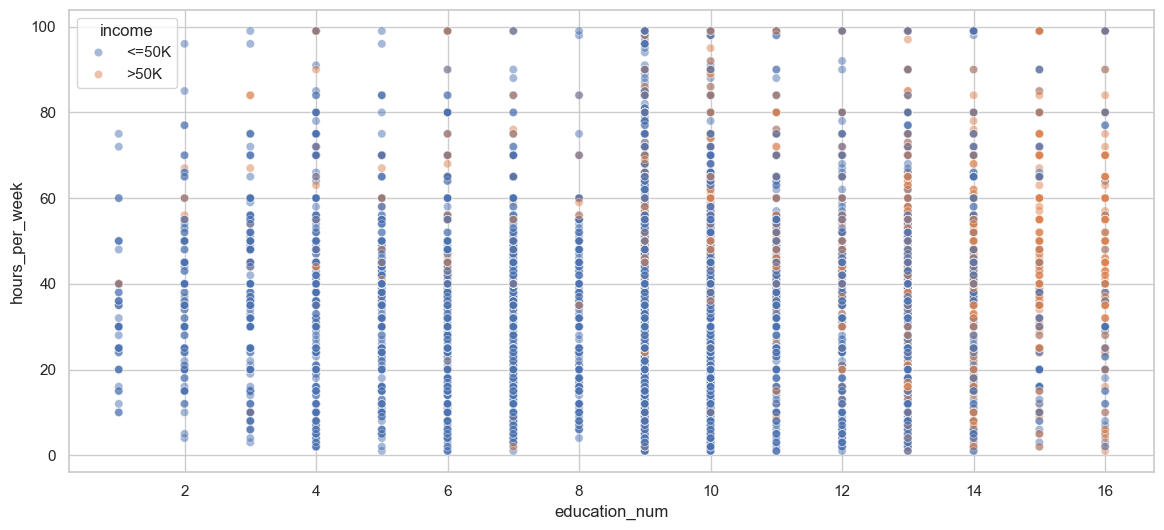

In [23]:
plt.figure(figsize=(14,6))
sns.scatterplot(x='education_num', y='hours_per_week', hue='income', data=df_train_test, alpha=0.5)

- This scatter plot shows that individuals with higher education levels (higher education_num) tend to work more hours per week, and among those, people earning >50K are more frequent at higher education levels and higher work hours, although there is still overlap between income groups at most education levels and hours worked.

<Axes: xlabel='age', ylabel='hours_per_week'>

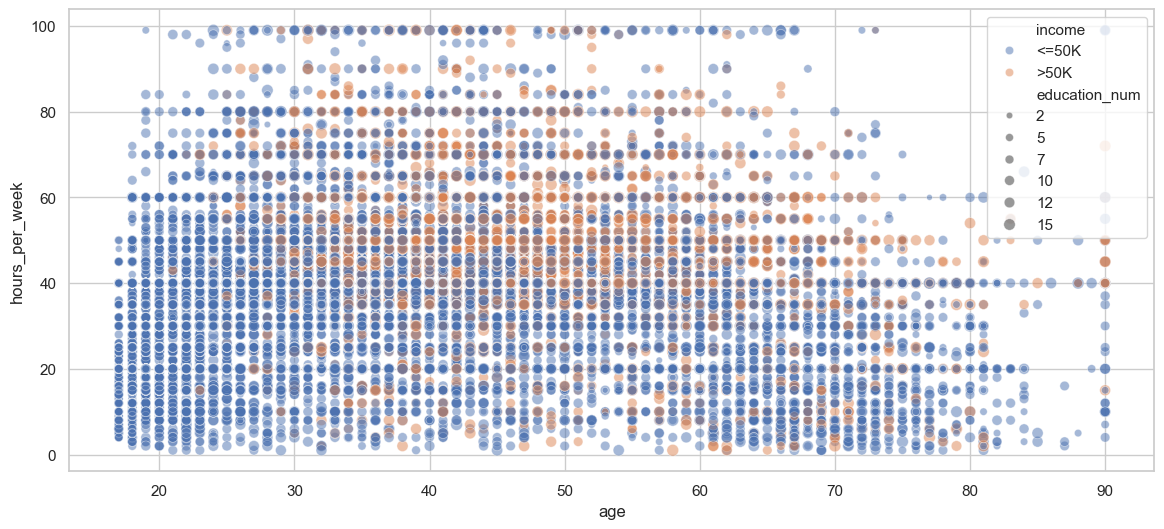

In [26]:
plt.figure(figsize=(14,6))
sns.scatterplot(x='age', y='hours_per_week', size='education_num', hue='income', data=df_train_test, alpha=0.5)

- This scatter plot shows how age and hours per week relate to income, with the size of each point representing education level. Higher income (>50K) individuals tend to be older, work more hours, and have higher education levels, although there is overlap between income groups across the age and hours worked ranges

#### check Multicolinearity - Two or more independent variables are highly correlated with each other
 - In regression models, high multicollinearity makes it hard to tell which variable is actually driving the target.
 - Coefficients become unstable or misleading.

In [29]:
X = df_train_test[['age', 'hours_per_week', 'education_num']]
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

          feature        VIF
0             age   7.101541
1  hours_per_week   9.370166
2   education_num  10.186207


#### Multivariate Analysis: Age, Hours per Week, Education vs Income

Analyzed how age, hours per week, and education level relate to income.

- VIF analysis shows multicollinearity (VIF > 7), indicating these features are highly correlated.  
- For regression models, we may need to remove or combine features to reduce multicollinearity.  
- Tree-based models can handle these features without issue.

# Net Capital vs Workclass by Income

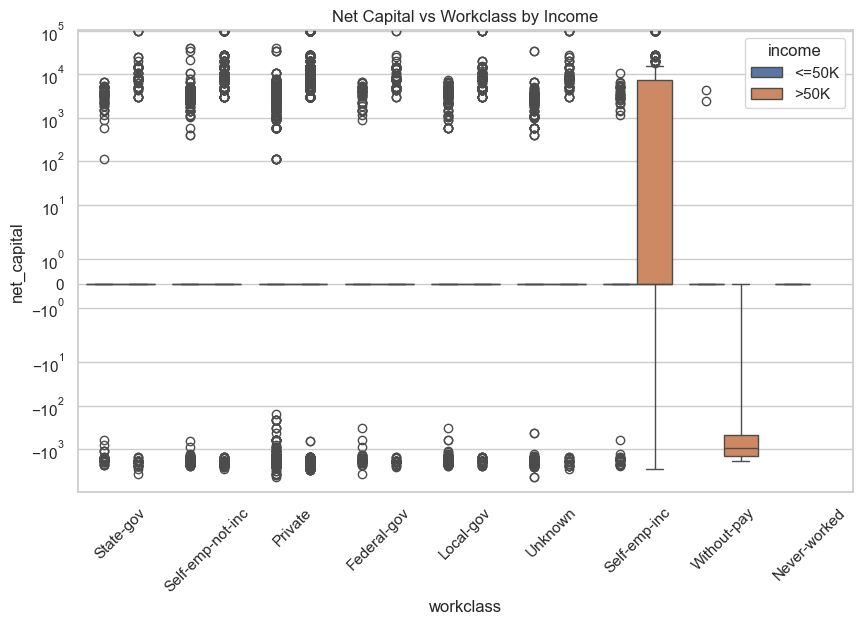

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(x='workclass', y='net_capital', hue='income', data=df_train_test)
plt.yscale('symlog')
plt.title('Net Capital vs Workclass by Income')
plt.xticks(rotation=45)
plt.show()

## summary

Across most workclasses, net capital remains near zero for both income groups. However, `Self-emp-inc` (incorporated self-employed) with `>50K` income shows notably higher net capital compared to all other workclasses, confirming that **self-employment combined with high net capital is a strong signal for >50K income**, making `workclass` a meaningful third variable in this analysis.

### Interaction :Marital Status × Sex vs Income

In [49]:
interaction_ms = pd.crosstab(
    [df_train_test['marital_status'], df_train_test['sex']],
    df_train_test['income'],
    normalize='index'
) * 100

interaction_ms.sort_values(by='>50K', ascending=False)

income                            <=50K       >50K
marital_status        sex                         
Married-civ-spouse    Female  55.201613  44.798387
                      Male    55.404183  44.595817
Married-AF-spouse     Female  60.000000  40.000000
                      Male    66.666667  33.333333
Widowed               Male    79.298246  20.701754
Divorced              Male    84.910680  15.089320
Married-spouse-absent Male    87.654321  12.345679
Separated             Male    88.146912  11.853088
Divorced              Female  93.148287   6.851713
Married-spouse-absent Female  94.078947   5.921053
Widowed               Female  94.403893   5.596107
Never-married         Male    94.666967   5.333033
                      Female  96.407767   3.592233
Separated             Female  96.992481   3.007519

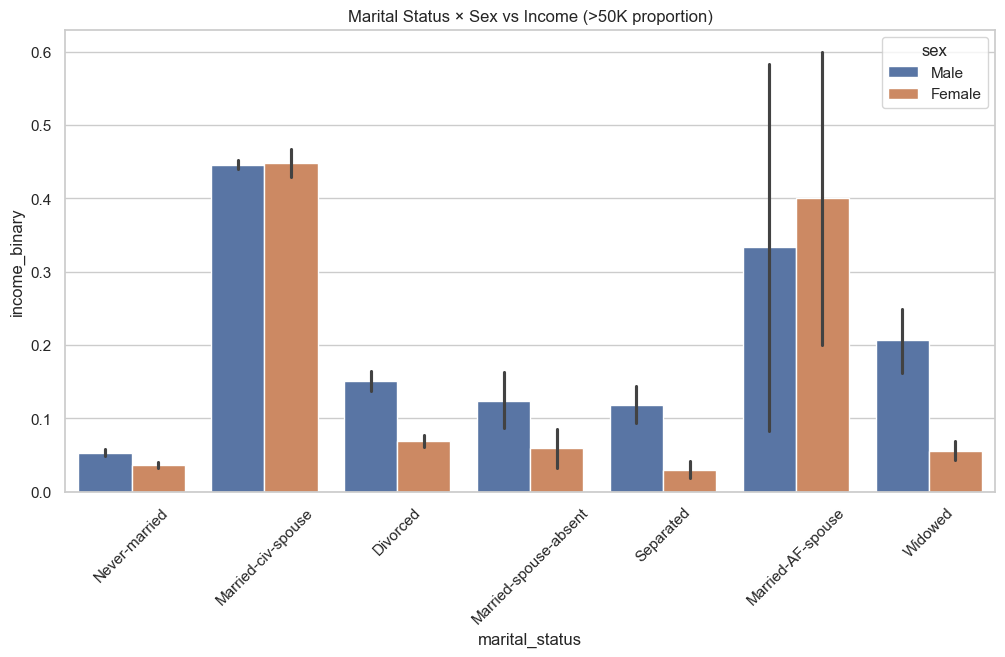

In [54]:
df_train_test['income_binary'] = df_train_test['income'].apply(lambda x: 1 if x == '>50K' else 0)

plt.figure(figsize=(12,6))
sns.barplot(
    x='marital_status',
    y='income_binary',
    hue='sex',
    data=df_train_test
)
plt.title('Marital Status × Sex vs Income (>50K proportion)')
plt.xticks(rotation=45)
plt.show()

<span style="color: blue;"> **Interaction Analysis: Marital Status × Sex vs Income**</span>

<span style="color: blue;">
Income distribution differs across combinations of marital status and sex. Married males show the highest percentage of individuals earning >50K, while never-married and female groups generally show lower high-income proportions.

This indicates an interaction effect, where the impact of marital status on income depends on gender.</span>

# Interaction effect : 
- Does the effect of education on income change depending on occupation?

In [52]:
# find % witing each combination
interaction_table = pd.crosstab([df_train_test['education'], df_train_test['occupation']], df_train_test['income'], normalize='index') * 100
interaction_table = interaction_table.sort_values(by='>50K', ascending=False)
interaction_table.head(10)

income                             <=50K        >50K
education   occupation                              
Doctorate   Protective-serv     0.000000  100.000000
Masters     Armed-Forces        0.000000  100.000000
Prof-school Armed-Forces        0.000000  100.000000
            Transport-moving    0.000000  100.000000
Doctorate   Machine-op-inspct   0.000000  100.000000
            Farming-fishing     0.000000  100.000000
Assoc-voc   Armed-Forces        0.000000  100.000000
Prof-school Protective-serv     0.000000  100.000000
Doctorate   Exec-managerial    14.285714   85.714286
Prof-school Prof-specialty     22.788606   77.211394

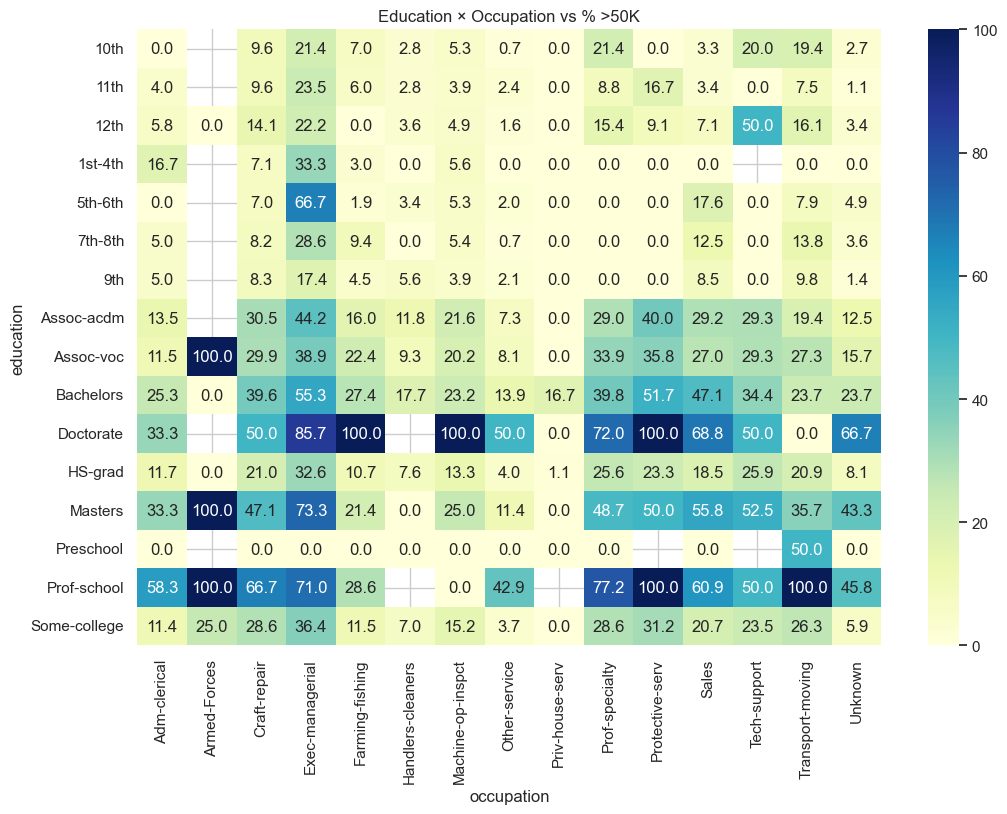

In [53]:
pivot_table = pd.pivot_table(
    df_train_test,
    values='income',
    index='education',
    columns='occupation',
    aggfunc=lambda x: (x == '>50K').mean() * 100
)
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Education × Occupation vs % >50K")
plt.show()

<span style="color: blue;"> **Interaction Analysis: Education × Occupation vs Income** </span>

<span style="color: blue;">
- The combined effect of education and occupation on income level.

- Higher income percentages change depending on both education and occupation. People with higher education earn more mainly in professional and managerial jobs, while the same education level in manual or service jobs does not lead to equally high income

- This indicates an interaction effect: the impact of education on income depends on occupation type.</span>

### How do numerical features correlate differently for low-income (<=50K) vs high-income (>50K) individuals?

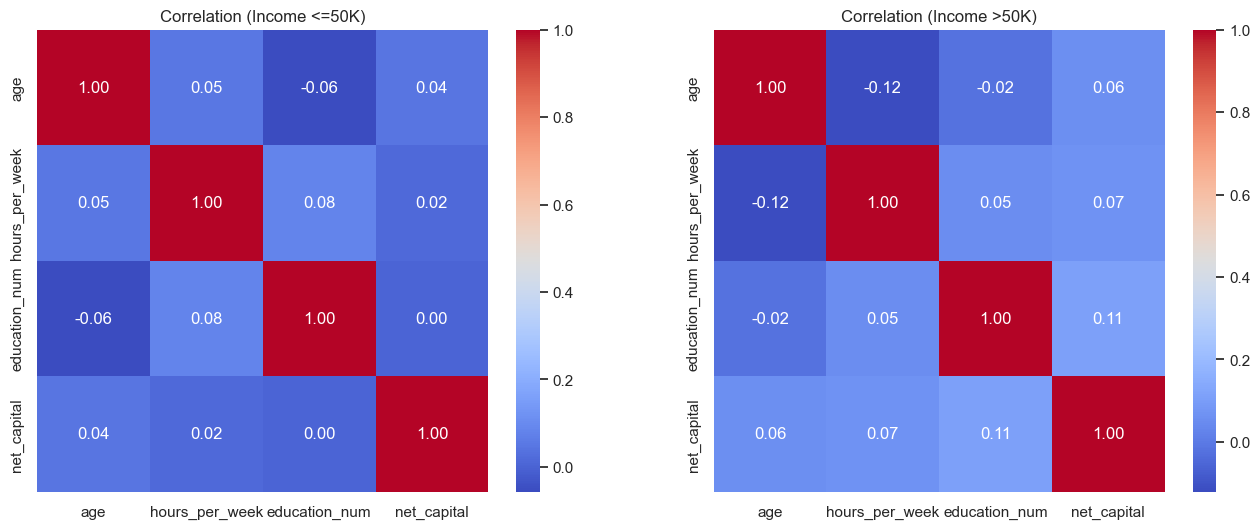

In [61]:
# Numerical columns
num_cols = ['age', 'hours_per_week', 'education_num', 'net_capital']

# Conditional correlation for income_binary = 0 (<=50K)
corr_le_50k = df_train_test[df_train_test['income_binary'] == 0][num_cols].corr()
# Conditional correlation for income_binary = 1 (>50K)
corr_gt_50k = df_train_test[df_train_test['income_binary'] == 1][num_cols].corr()

# Plot heatmaps side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(corr_le_50k, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Correlation (Income <=50K)")

sns.heatmap(corr_gt_50k, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation (Income >50K)")

plt.show()

### Numerical features show low correlation in both income groups, so all can be used together, with only a slight positive link between education_num and net_capital among high earners